In [3]:
import time
import numpy as np
from decimal import Decimal, getcontext
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Happy $\pi$ Day!

Let's look at some formulae for $\pi$. 

## Archimedes' Polygons
One of the oldest ways to calculate $\pi$ is by bounding a circle between two regular polygons. Here's a function which visualizes the geometry. 

In [17]:
def visualize_archimedes_method(n):
    """
    Inputs n (>= 3) and outputs a visualization of a unit circle with 
    an inscribed and a circumscribed regular n-gon.
    """
    if n < 3:
        raise ValueError("The number of sides 'n' must be at least 3.")

    # 1. Setup the figure and axis
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.set_aspect('equal') # Crucial for keeping the circle circular
    ax.grid(True, linestyle='--', alpha=0.5)

    # 2. Draw the Unit Circle (Radius = 1, Diameter = 2)
    # The true boundary we are approximating is its circumference, 2*pi
    circle = plt.Circle((0, 0), 1, color='black', fill=False, linewidth=2, label='Unit Circle (Circumference 2$\\pi$)')
    ax.add_artist(circle)

    # 3. Generate vertices for the polygons
    # Angles for the vertices (starting at 0 rad, ending just before 2*pi)
    angles = np.linspace(0, 2 * np.pi, n, endpoint=False)

    # --- Geometry for the Inscribed Poly ---
    # Radius = R_circle = 1.
    inscribed_vertices = np.column_stack([np.cos(angles), np.sin(angles)])

    # --- Geometry for the Circumscribed Poly ---
    # Side length (s) and Apothem (a). We need to scale the vertices.
    # The circle's radius (1) is the apothem of the outer polygon.
    apothem_outer = 1.0
    # Formula for apothem (a) and circumradius (R): a = R * cos(pi/n)
    # Therefore, the radius of the circumscribed polygon's vertices is:
    circumradius_outer = apothem_outer / np.cos(np.pi / n)
    circumscribed_vertices = np.column_stack([
        circumradius_outer * np.cos(angles),
        circumradius_outer * np.sin(angles)
    ])

    # 4. Add the polygons to the plot
    in_poly = patches.Polygon(inscribed_vertices, closed=True, 
                             edgecolor='#1f77b4', facecolor='#1f77b440', 
                             linewidth=2.5, label=f'Inscribed {n}-gon (Lower Bound)')
    
    out_poly = patches.Polygon(circumscribed_vertices, closed=True, 
                              edgecolor='#d62728', facecolor='#d6272840', 
                              linewidth=2.5, linestyle='-', label=f'Circumscribed {n}-gon (Upper Bound)')

    ax.add_patch(out_poly) # Add outer first so it's 'behind' the circle/inner
    ax.add_patch(in_poly)

    # 5. Calculate and display numerical approximations
    # We compare the semi-perimeters (Perimeter/2) because we are finding PI, not 2*PI.
    # We use a unit diameter circle (R=1), so SemiPerimeter = Polygon Perimeter / 2.
    # Alternatively, use the regular polygon area formula: Area = n * R^2 * sin(2*pi/n) / 2
    # But semi-perimeter is truer to Archimedes' original idea.

    # Perimeter = n * s. We need s_in and s_out.
    # s_in = 2 * R_in * sin(pi/n) = 2 * sin(pi/n)
    perimeter_in = n * (2 * np.sin(np.pi / n))
    semi_perimeter_in = perimeter_in / 2.0

    # s_out = 2 * a_out * tan(pi/n) = 2 * tan(pi/n)
    perimeter_out = n * (2 * np.tan(np.pi / n))
    semi_perimeter_out = perimeter_out / 2.0

    # 6. Formatting the plot
    ax.set_xlim(-1.6, 1.6)
    ax.set_ylim(-1.6, 1.6)
    
    # Text box for data
    data_text = (
        f"Archimedes' Bracketing:\n"
        f"{n}-gon Semi-Perimeters\n"
        f"________________________\n\n"
        f"Lower: {semi_perimeter_in:.10f}\n"
        f"True $\\pi$: {np.pi:.10f}...\n"
        f"Upper: {semi_perimeter_out:.10f}\n\n"
        f"Error range: $\\pm${(semi_perimeter_out - np.pi):.5f}"
    )
    plt.text(-1.55, 1.55, data_text, fontsize=11, family='monospace',
             verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    ax.set_title(f"Archimedes' Method Visualization: n={n}", fontsize=16)
    ax.legend(loc='lower center', fontsize=10, framealpha=1, bbox_to_anchor=(0.5, -0.15), ncol=1)
    
    # Final plot generation (required to view the diagram)
    plt.show()

Let's look at the simple case of a regular 4-sided polygon, a.k.a. a square.

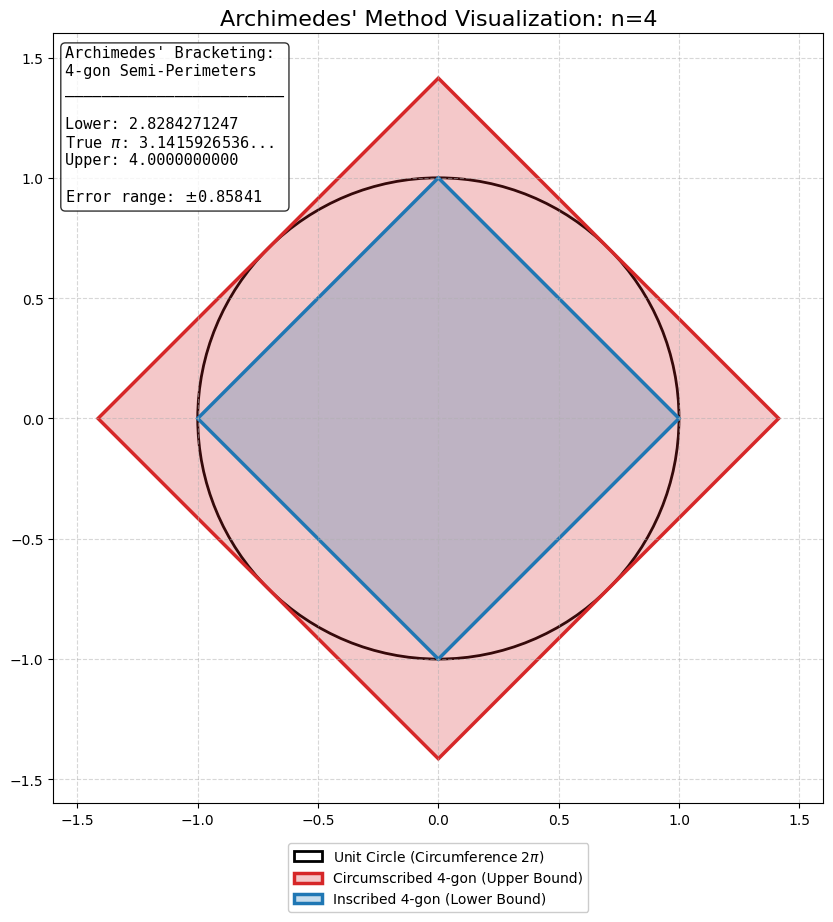

In [18]:
visualize_archimedes_method(4)